# Aula 4 — EDA Profissional (Versão Avançada) - Para Aula
**Dataset:** Airbnb NYC

## Objetivos Desta Aula
- **Explorar um dataset real de mercado:** Entender a estrutura e o conteúdo de dados reais.
- **Detectar e tratar valores faltantes e outliers:** Aprender técnicas para limpar e preparar os dados.
- **Realizar análise por categoria e por localização:** Investigar padrões e tendências em diferentes segmentos e regiões.
- **Construir gráficos profissionais e informativos:** Utilizar bibliotecas avançadas para visualizações de alta qualidade.
- **Introduzir correlação entre variáveis:** Entender as relações entre diferentes atributos do dataset.
- **Engenharia de Features:** Criar novas variáveis para enriquecer a análise.
- **Análise Geoespacial:** Visualizar dados em um contexto geográfico.
- **Interpretar e comunicar insights:** Extrair conclusões significativas dos dados.


## 1) Importação das bibliotecas Essenciais
Nesta seção, importamos todas as bibliotecas Python necessárias para a Análise Exploratória de Dados (EDA).

- `pandas`: Para manipulação e análise de dados em formato de DataFrame.
- `matplotlib.pyplot`: Para a criação de gráficos estáticos.
- `seaborn`: Baseado no matplotlib, oferece uma interface de alto nível para criar gráficos estatísticos atraentes e informativos.
- `numpy`: Para operações numéricas e matemáticas, especialmente útil para lidar com arrays e cálculos estatísticos.
- `folium`: Para criar mapas interativos e visualizar dados geoespaciais.


In [1]:
# Importe aqui as bibliotecas necessárias: pandas, matplotlib.pyplot, seaborn, numpy, folium
# Configure os estilos de visualização (sns.set_style, plt.rcParams)
%pip install pandas
%pip install seaborn
%pip install numpy
%pip install folium
%pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import folium as folium

sns.set_style('darkgrid')
plt.rcParams.update({
    'figure.figsize' : (12,6),
    'figure.dpi': 100,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'grid.alpha': 0.3,
})


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## 2) Carregar o Dataset
Carregamos o dataset do Airbnb NYC a partir de um arquivo CSV. Este é o primeiro passo para qualquer análise de dados, onde os dados brutos são lidos e transformados em um DataFrame do pandas para fácil manipulação.


In [2]:
# Carregue o arquivo CSV "AB_NYC_2019.csv" em um DataFrame do pandas
# Exiba as primeiras linhas do DataFrame para uma visão inicial dos dados

df = pd.read_csv('AB_NYC_2019.csv')
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149.0,1.0,9.0,2018-10-19,0.21,6.0,365.0
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225.0,1.0,45.0,2019-05-21,0.38,2.0,355.0
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150.0,3.0,0.0,NaN,NaN,1.0,365.0
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89.0,1.0,270.0,2019-07-05,4.64,1.0,194.0
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80.0,10.0,9.0,2018-11-19,0.10,1.0,0.0


## 3) Visão Geral e Estrutura dos Dados
Esta seção fornece uma visão geral rápida do dataset, incluindo suas dimensões, tipos de dados e um resumo estatístico. Isso nos ajuda a entender a estrutura dos dados e identificar possíveis problemas, como valores ausentes ou tipos de dados incorretos.


In [12]:
# Exiba o número de linhas e colunas do DataFrame (df.shape)
# Exiba informações sobre o DataFrame, incluindo tipos de dados e valores não-nulos (df.info())
# Exiba estatísticas descritivas para as colunas numéricas (df.describe())
# Exiba estatísticas descritivas para todas as colunas (incluindo categóricas) (df.describe(include="all"))
df.shape
df.info()
df.describe()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7391 entries, 0 to 7390
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              7391 non-null   int64  
 1   name                            7384 non-null   object 
 2   host_id                         7391 non-null   int64  
 3   host_name                       7386 non-null   object 
 4   neighbourhood_group             7391 non-null   object 
 5   neighbourhood                   7391 non-null   object 
 6   latitude                        7391 non-null   float64
 7   longitude                       7391 non-null   float64
 8   room_type                       7390 non-null   object 
 9   price                           7390 non-null   float64
 10  minimum_nights                  7390 non-null   float64
 11  number_of_reviews               7390 non-null   float64
 12  last_review                     65

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,7.391000e+03,7384,7.391000e+03,7386,7391,7391,7391.000000,7391.000000,7390,7390.000000,7390.000000,7390.000000,6567,6567.000000,7390.000000,7390.000000
unique,NaN,7345,NaN,3020,5,163,NaN,NaN,3,NaN,NaN,NaN,1408,NaN,NaN,NaN
top,NaN,Loft Suite @ The Box House Hotel,NaN,Michael,Manhattan,Williamsburg,NaN,NaN,Entire home/apt,NaN,NaN,NaN,2019-06-23,NaN,NaN,NaN
freq,NaN,11,NaN,79,3420,696,NaN,NaN,4417,NaN,NaN,NaN,192,NaN,NaN,NaN
mean,2.443569e+06,NaN,7.922206e+06,NaN,NaN,NaN,40.729248,-73.950496,NaN,167.145873,8.530717,50.785792,NaN,0.897995,2.636130,133.241678
std,1.689463e+06,NaN,7.639974e+06,NaN,NaN,NaN,0.051749,0.779693,NaN,278.992369,29.761734,72.709536,NaN,1.133974,6.907491,138.350376
min,2.539000e+03,NaN,2.571000e+03,NaN,NaN,NaN,40.508680,-74.239860,NaN,10.000000,1.000000,0.000000,NaN,0.010000,1.000000,0.000000
25%,8.227680e+05,NaN,1.599930e+06,NaN,NaN,NaN,40.688775,-73.984005,NaN,80.000000,2.000000,4.000000,NaN,0.130000,1.000000,0.000000
50%,2.224896e+06,NaN,5.076827e+06,NaN,NaN,NaN,40.723220,-73.959300,NaN,120.000000,3.000000,18.000000,NaN,0.420000,1.000000,81.000000
75%,4.032019e+06,NaN,1.198219e+07,NaN,NaN,NaN,40.763785,-73.943620,NaN,185.000000,5.000000,67.000000,NaN,1.250000,2.000000,273.000000


## 4) Tratamento de Valores Faltantes
Valores faltantes são comuns em datasets reais e podem afetar a qualidade da análise. Nesta seção, identificamos e tratamos esses valores, decidindo entre remover, preencher com um valor específico (média, mediana, moda) ou usar métodos mais avançados.




In [13]:
# Calcule e exiba a quantidade de valores faltantes por coluna
# Preencha os valores faltantes nas colunas `name` e `host_name` com "unknown"
# Preencha os valores faltantes na coluna `reviews_per_month` com 0
# Converta a coluna `last_review` para datetime e preencha os valores faltantes com uma data de referência (e.g., "2010-01-01")
# Verifique novamente os valores faltantes após o tratamento
print("Valores faltantes sao:\n",df.isna().sum())
df["name"] = df["name"].fillna("unknown")
df["host_name"]  = df["host_name"].fillna("unknown")
df["reviews_per_month"] =  df["reviews_per_month"].fillna(0)
df["last_review"] = pd.to_datetime(df["last_review"],errors ="coerce")
df["last_review"] = df["last_review"].fillna(pd.Timestamp("2010-01-01"))
print("Os valores faltantes apos o tratamento sao: \n ",df.isna().sum())

Valores faltantes sao:
 id                                  0
name                                7
host_id                             0
host_name                           5
neighbourhood_group                 0
neighbourhood                       0
latitude                            0
longitude                           0
room_type                           1
price                               1
minimum_nights                      1
number_of_reviews                   1
last_review                       824
reviews_per_month                 824
calculated_host_listings_count      1
availability_365                    1
dtype: int64
Os valores faltantes apos o tratamento sao: 
  id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type           

## 5) Detecção e Tratamento de Outliers
Outliers são pontos de dados que se desviam significativamente de outras observações. Eles podem distorcer análises estatísticas e modelos de machine learning. Nesta seção, identificamos e tratamos outliers em variáveis numéricas chave, como `price` e `minimum_nights`. Usaremos o método do Intervalo Interquartil (IQR) para uma abordagem robusta.


In [33]:
# Defina uma função `remove_outliers_iqr` para detectar e remover outliers usando o método IQR
# Aplique a função para tratar outliers nas colunas `price`, `minimum_nights` e `number_of_reviews`
# Exiba as estatísticas descritivas antes e depois do tratamento para cada coluna
# Atualize o DataFrame principal com os dados limpos
def remover_outilers_iqr(df, coluna):
    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)
    IQR = Q3-Q1

    limite_superior=Q3+1.5 * IQR
    limite_inferior=Q1-1.5 * IQR
    df_filtro = df[(df[coluna] >= limite_inferior) & (df[coluna]<= limite_superior)]
    return df_filtro

print("Estatisticas antes dos tratamentos dos Outliers: \n")
print(df[['price', 'minimum_nights', 'number_of_reviews']].describe())

colunas_tratar= ['price', 'minimum_nights', 'number_of_reviews']

for col in colunas_tratar:
    df=remover_outilers_iqr(df, col)

print("Estatisticas apos os tratamentos dos Outliers \n")
print(df[['price', 'minimum_nights', 'number_of_reviews']].describe())


Estatisticas antes dos tratamentos dos Outliers: 

             price  minimum_nights  number_of_reviews
count  5036.000000     5036.000000        5036.000000
mean    130.412629        2.979349          35.241461
std      64.991190        1.752391          41.382956
min      16.000000        1.000000           0.000000
25%      79.000000        2.000000           3.000000
50%     120.000000        3.000000          17.000000
75%     175.000000        4.000000          55.000000
max     305.000000        7.000000         156.000000
Estatisticas apos os tratamentos dos Outliers 

             price  minimum_nights  number_of_reviews
count  4825.000000     4825.000000        4825.000000
mean    130.687254        3.000207          30.458653
std      65.228465        1.767415          35.207046
min      16.000000        1.000000           0.000000
25%      79.000000        2.000000           3.000000
50%     120.000000        3.000000          15.000000
75%     175.000000        4.000000   

## 6) Análise Exploratória de Dados (EDA) Aprofundada
Com os dados limpos, podemos agora aprofundar nossa análise, explorando as distribuições das variáveis, as relações entre elas e identificando padrões que podem gerar insights valiosos.


### 6.1) Distribuição de Preços
Vamos visualizar a distribuição dos preços dos aluguéis para entender a faixa de valores e identificar a concentração de preços.


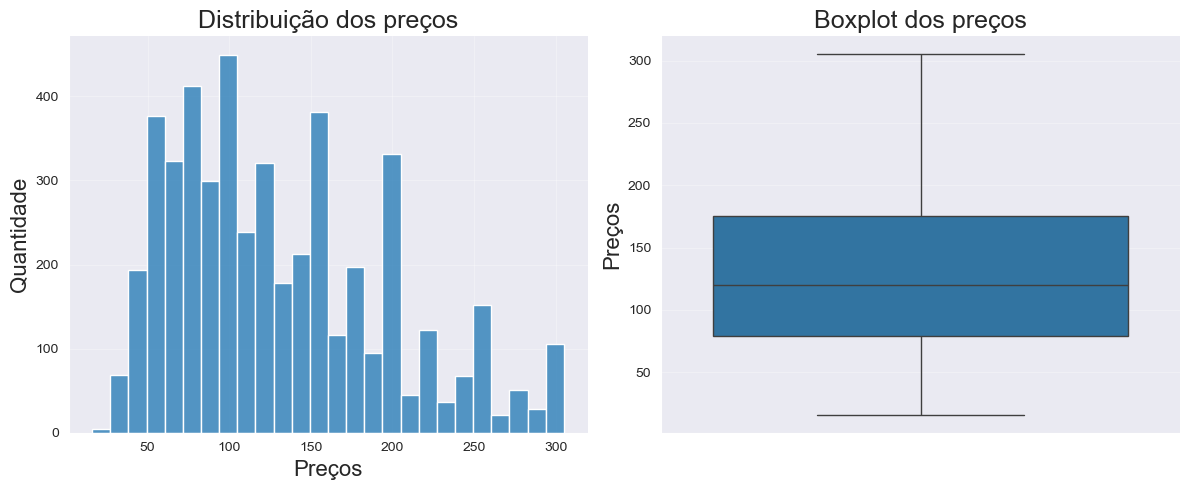

In [47]:
# Crie um histograma da coluna `price` usando `sns.histplot`
# Crie um boxplot da coluna `price` usando `sns.boxplot`
# Adicione títulos e rótulos aos gráficos

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df["price"])
plt.title("Distribuição dos preços")
plt.xlabel("Preços")
plt.ylabel("Quantidade")

plt.subplot(1,2,2)
sns.boxplot(y=df["price"])
plt.title("Boxplot dos preços")
plt.ylabel("Preços")

plt.tight_layout()
plt.show()


### 6.2) Análise por Tipo de Quarto (`room_type`)
Entender a distribuição dos tipos de quartos e como eles se relacionam com o preço é crucial para proprietários e hóspedes.


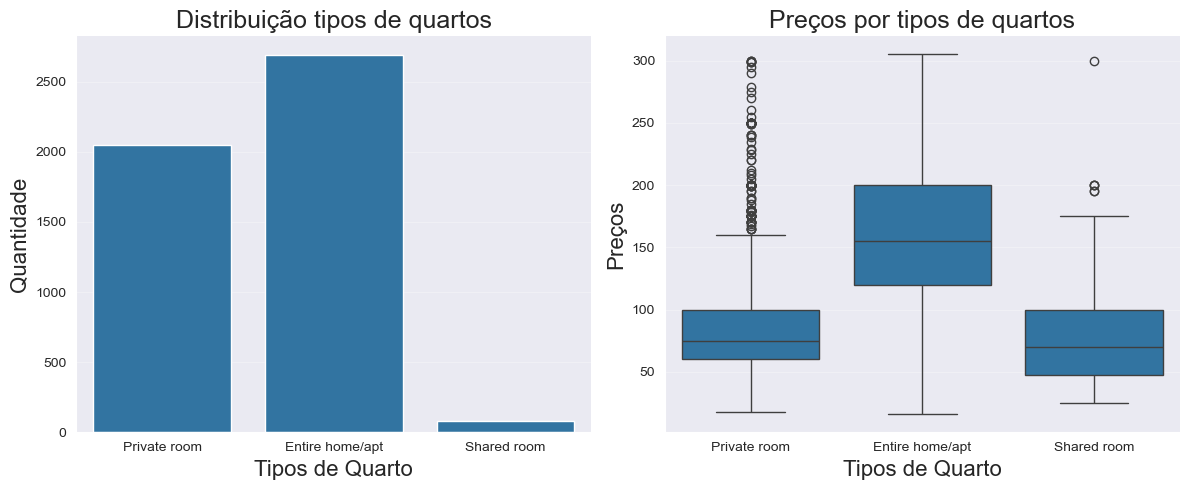

In [51]:
# Crie um gráfico de contagem dos tipos de quarto usando `sns.countplot`
# Crie um boxplot do preço por tipo de quarto usando `sns.boxplot`
# Adicione títulos e rótulos aos gráficos
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.countplot(x="room_type",data=df)
plt.title("Distribuição tipos de quartos")
plt.xlabel("Tipos de Quarto")
plt.ylabel("Quantidade")

plt.subplot(1,2,2)
sns.boxplot(x="room_type", y="price",data=df)
plt.title("Preços por tipos de quartos")
plt.ylabel("Preços")
plt.xlabel("Tipos de Quarto")

plt.tight_layout()
plt.show()


### 6.3) Análise por Grupo de Bairro (`neighbourhood_group`)
A localização é um dos fatores mais importantes no mercado imobiliário. Vamos analisar como os preços e a disponibilidade variam entre os diferentes grupos de bairros de NYC.


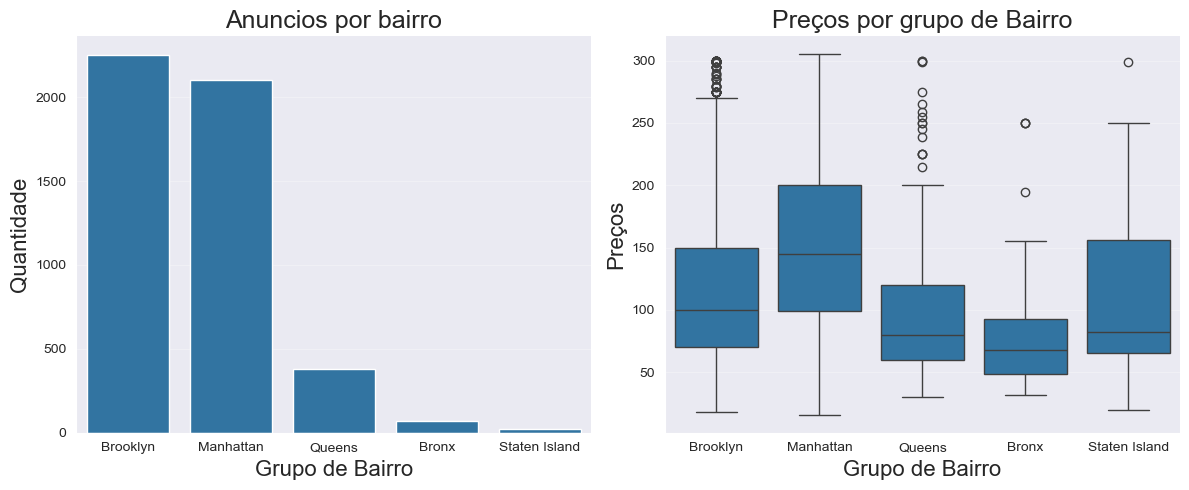

In [52]:
# Crie um gráfico de contagem de anúncios por grupo de bairro usando `sns.countplot`
# Crie um boxplot do preço por grupo de bairro usando `sns.boxplot`
# Adicione títulos e rótulos aos gráficos
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.countplot(x="neighbourhood_group",data=df)
plt.title("Anuncios por bairro")
plt.xlabel("Grupo de Bairro")
plt.ylabel("Quantidade")

plt.subplot(1,2,2)
sns.boxplot(x="neighbourhood_group", y="price",data=df)
plt.title("Preços por grupo de Bairro")
plt.ylabel("Preços")
plt.xlabel("Grupo de Bairro")

plt.tight_layout()
plt.show()

### 6.4) Top 10 Bairros com Mais Anúncios
Identificar os bairros com maior concentração de anúncios pode indicar áreas de alta demanda ou popularidade.


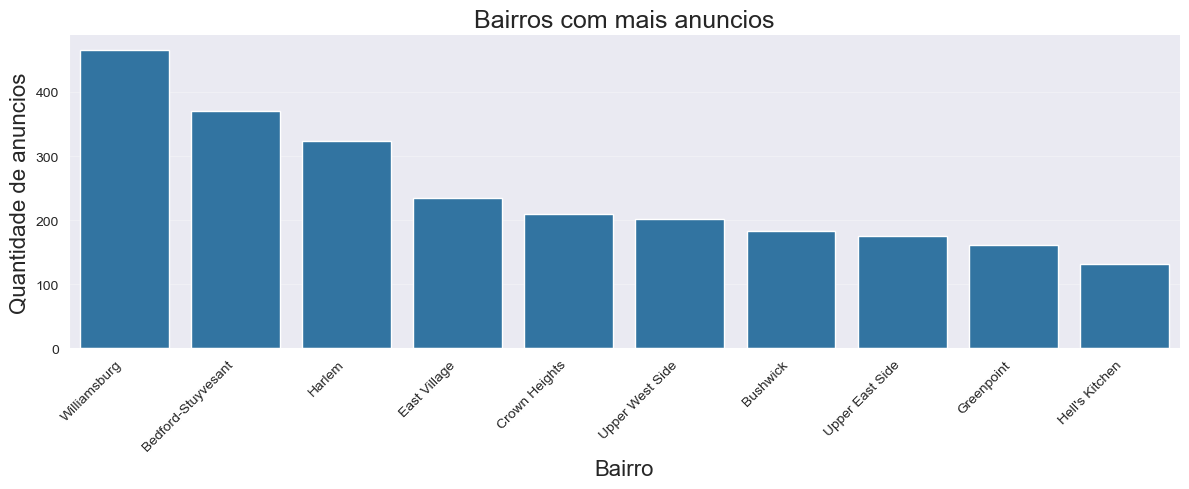

In [59]:
# Calcule os 10 bairros com mais anúncios
# Crie um gráfico de barras para visualizar esses bairros usando `sns.barplot`
# Adicione títulos e rótulos aos gráficos, e rotacione os rótulos do eixo X se necessário
top10_bairro = df['neighbourhood'].value_counts().head(10).reset_index()
top10_bairro.columns = ['neighbourhood','quantidade']
plt.figure(figsize=(12,5))
sns.barplot(data=top10_bairro,x='neighbourhood',y='quantidade')
plt.title('Bairros com mais anuncios')
plt.xlabel('Bairro')
plt.ylabel('Quantidade de anuncios')
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()

### 6.5) Análise Geoespacial dos Anúncios
Visualizar os anúncios em um mapa nos permite identificar clusters geográficos e entender a distribuição espacial dos imóveis.


In [68]:
# Crie um mapa base de Nova York usando `folium.Map`
# Adicione um `MarkerCluster` ao mapa
# Amostre uma parte do DataFrame (e.g., 5000 pontos) para melhor performance na visualização
# Adicione marcadores ao mapa para cada ponto amostrado, incluindo informações no popup
# Salve o mapa em um arquivo HTML (e.g., "airbnb_nyc_map.html")
# (Opcional) Exiba o mapa diretamente no notebook se o ambiente suportar
from folium.plugins import MarkerCluster
mapa = folium.Map( location=[40.7128, -74.0060],zoom_start=10)
cluster = MarkerCluster()

df_amostra = df.sample(n=3000, random_state=42)

for _,row in df_amostra.iterrows() :
    popup_texto = f"""
    <b>{row['name']}</b><br>
    Bairro: {row['neighbourhood']}<br>
    Tipo: {row['room_type']}<br>
    Preço: R${row['price']}
    """
    folium.Marker(
     location=[row['latitude'],row['longitude']],
     popup=folium.Popup(popup_texto, max_width = 250)
    ).add_to(cluster)
cluster.add_to(mapa)

mapa.save("airbnb_nyc_map.html")

mapa

## 7) Engenharia de Features
A engenharia de features envolve a criação de novas variáveis a partir das existentes para melhorar a capacidade preditiva dos modelos ou para obter novos insights. Aqui, criaremos algumas features simples.


### 7.1) `host_experience_days`
Calcularemos a experiência do anfitrião em dias, baseando-nos na data da última avaliação (`last_review`) e uma data de referência (ou a data da primeira avaliação, se disponível). Isso pode indicar a longevidade e experiência do anfitrião na plataforma.


In [3]:
# Calcule a data mais recente de `last_review`
# Crie a nova feature `host_experience_days` calculando a diferença em dias entre a data mais recente e `last_review`
# Exiba as estatísticas descritivas da nova feature
df['last_review'] = pd.to_datetime(df['last_review'])

data_recente = df['last_review'].max()

df['host_experience_days'] = (data_recente-df['last_review']).dt.days

print(df['host_experience_days'].describe())

count    6567.000000
mean      431.956906
std       574.902778
min         0.000000
25%        19.000000
50%        93.000000
75%       750.000000
max      3024.000000
Name: host_experience_days, dtype: float64


### 7.2) `price_per_night_per_review`
Esta feature pode indicar o custo-benefício percebido, relacionando o preço por noite com o número de avaliações. Um valor baixo pode indicar um bom negócio, enquanto um valor alto pode sugerir um preço elevado para poucos reviews.


In [4]:
# Crie a nova feature `price_per_night_per_review`, dividindo `price` por `number_of_reviews`
# Lembre-se de tratar a divisão por zero (e.g., se `number_of_reviews` for 0, use o próprio `price`)
# Exiba as estatísticas descritivas da nova feature
df['price_per_night_per_review'] = np.where(
    df['number_of_reviews']>0,
    df['price']/df['number_of_reviews'],
    df['price']
)

print(df['price_per_night_per_review'].describe())

count    7390.000000
mean       52.263063
std       239.643901
min         0.075130
25%         1.685474
50%         7.047118
75%        36.583333
max      9999.000000
Name: price_per_night_per_review, dtype: float64


## 8) Análise de Correlação
A correlação mede a força e a direção da relação linear entre duas variáveis numéricas. Um mapa de calor (heatmap) da matriz de correlação é uma excelente ferramenta para visualizar essas relações.


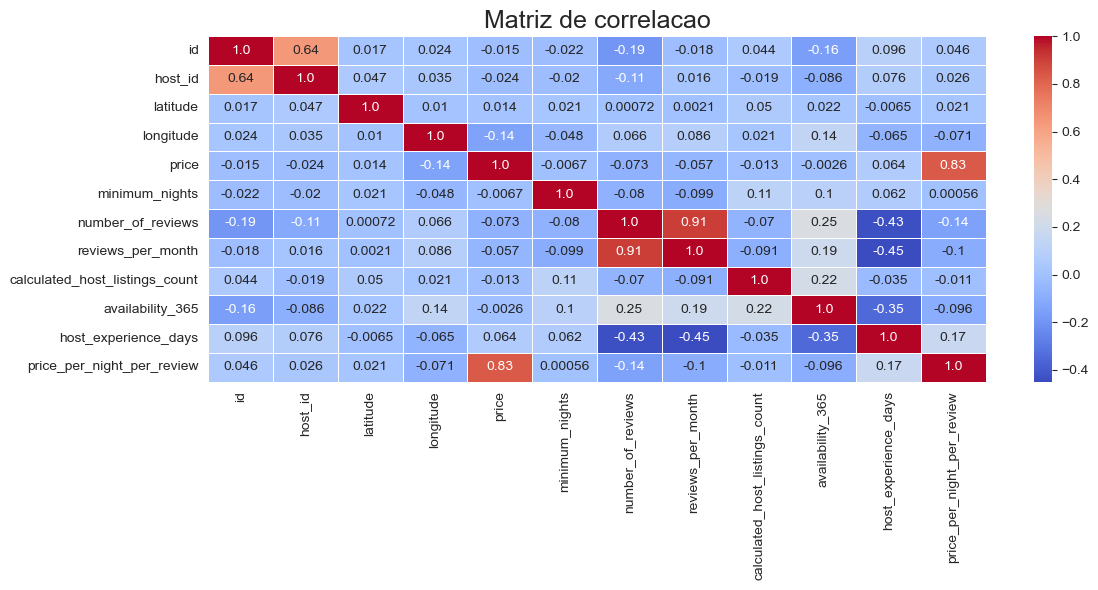

In [7]:
# Selecione apenas as colunas numéricas do DataFrame
# Calcule a matriz de correlação
# Crie um heatmap da matriz de correlação usando `sns.heatmap`
# Adicione anotações e um mapa de cores adequado
# Adicione um título ao gráfico

df_numero = df.select_dtypes(include='number')

correlacao = df_numero.corr()

plt.Figure(figsize=(14,10))

sns.heatmap(
    correlacao,
    annot=True,
    fmt='.2',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Matriz de correlacao')
plt.tight_layout()
plt.show()